In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

import clickhouse_connect

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Make sure wide DataFrames don't wrap
pd.set_option("display.width", None)

# Show the full content of each column (no '...')
pd.set_option("display.max_colwidth", None)

In [2]:
client = clickhouse_connect.get_client(
    host='yaujulxk39.eastus2.azure.clickhouse.cloud',      # or server IP
    port=8443,             # HTTP port (default)
    username='default',
    password='~gZjRLjjOJh1i',
    database='Competitive_Analysis'
)

In [3]:
# ---- Query ----
df_hum_hist = client.query_df("""
    SELECT *
    FROM Competitive_Analysis.DRGHistoricalReviewInformation
    WHERE Client = 'Hum'
""")
df_hum_hist.shape

(76355, 291)

In [4]:
# -------------------------------------------------
# Initial shape of the dataset
# -------------------------------------------------
df_hum = df_hum_hist.copy()

print(df_hum.shape)  

df_hum = df_hum[df_hum['InitialDenialType'] == 'Substantive']
print(df_hum.shape) 

# -------------------------------------------------
# Identify valid Group_Type values
# -------------------------------------------------

group_type_unique = df_hum['Group_Type'].dropna().unique()
print(group_type_unique) 

# -------------------------------------------------
# Filter dataset to only valid Group_Type rows
# Use .copy() to avoid SettingWithCopyWarning
# -------------------------------------------------
df_hum_group_type = df_hum[df_hum['Group_Type'].isin(group_type_unique)].copy()
print(df_hum_group_type.shape) 

# -------------------------------------------------
# Calculate ADRG length
# -------------------------------------------------
df_hum_group_type.loc[:, 'len_adrg'] = (
    df_hum_group_type['ADRG'].astype(str).str.len()
)

print(df_hum_group_type['len_adrg'].value_counts())
print(df_hum_group_type['Group_Type'].value_counts())

# -------------------------------------------------
# Remove invalid DRG / Group_Type combinations
#   1) Group_Type = '01' and ADRG length = 4
#   2) Group_Type = '10' and ADRG length = 3
# -------------------------------------------------
mask_remove = (
    ((df_hum_group_type['Group_Type'] == '01') & (df_hum_group_type['len_adrg'] == 4)) |
    ((df_hum_group_type['Group_Type'] == '10') & (df_hum_group_type['len_adrg'] == 3))
)

df_hum_drg_rem = df_hum_group_type.loc[~mask_remove].copy()
print(df_hum_drg_rem.shape)

# -------------------------------------------------
# Create a copy of InitialDeterminationDate
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = (
    df_hum_drg_rem['InitialDeterminationDate']
)

print(
    df_hum_drg_rem['Control_ID']
    .value_counts()
    .sort_values(ascending=False)
    .head()
)

# -------------------------------------------------
# Convert date column to datetime
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = pd.to_datetime(
    df_hum_drg_rem['InitialDeterminationDate_copy'],
    errors='coerce'
)

# -------------------------------------------------
# Keep latest record per Control_ID
# -------------------------------------------------
df_sorted = df_hum_drg_rem.sort_values(
    'InitialDeterminationDate_copy',
    ascending=False
)

df_hum_latest = df_sorted.drop_duplicates(
    subset='Control_ID',
    keep='first'
).copy()

print(df_hum_latest.shape)

# -------------------------------------------------
# Normalize string columns
# -------------------------------------------------
df_hum_latest.loc[:, 'ADRG'] = (
    df_hum_latest['ADRG'].astype(str).str.strip()
)

df_hum_latest.loc[:, 'PRIM_DX'] = (
    df_hum_latest['PRIM_DX'].astype(str).str.strip().str.upper()
)

df_hum_latest.loc[:, 'InitialDeterminationStatus'] = (
    df_hum_latest['InitialDeterminationStatus']
    .astype(str)
    .str.strip()
    .str.upper()
)

# -------------------------------------------------
# Clean numeric fields
# -------------------------------------------------
df_hum_latest.loc[:, 'IDSavings'] = (
    pd.to_numeric(df_hum_latest['IDSavings'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'LOS'] = (
    pd.to_numeric(df_hum_latest['LOS'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'AGE'] = (
    pd.to_numeric(df_hum_latest['AGE'], errors='coerce')
)

# -------------------------------------------------
# Validate AGE values
# -------------------------------------------------
max_age = df_hum_latest['AGE'].max()

df_hum_latest = df_hum_latest[(
    df_hum_latest['AGE'].between(0, max_age))
].copy()
df_hum_latest.loc[:, 'AGE'] = df_hum_latest['AGE'].astype('Int64')
print(df_hum_latest.shape)

# -------------------------------------------------
# Validate LOS values
# -------------------------------------------------
df_hum_latest.loc[:, 'LOS'] = (
    df_hum_latest['LOS'].astype('Int64')
)

df_hum_latest = df_hum_latest[(df_hum_latest['LOS'] >= 0)].copy()
print(df_hum_latest.shape)

# -------------------------------------------------
# Remove extreme savings outliers
# -------------------------------------------------
df_hum_latest = df_hum_latest[
    df_hum_latest['IDSavings'] < 650000
].reset_index(drop=True)

print(df_hum_latest.shape)

# Date only
df_hum_latest['InitialDeterminationDate_date'] = (
    df_hum_latest['InitialDeterminationDate'].dt.date
)

# Year
df_hum_latest['InitialDetermination_Year'] = (
    df_hum_latest['InitialDeterminationDate'].dt.year
)

df_hum_latest["InitialDeterminationDate_date"] = pd.to_datetime(
    df_hum_latest["InitialDeterminationDate_date"],
    errors="coerce"   # handles bad / empty values safely
)


df_hum_latest['InitialDeterminationStatus_Flag'] = (
    df_hum_latest['InitialDeterminationStatus']
    .str.strip()
    .str.upper()
    .map({
        'APPROVED': 0,
        'DENIED': 1
    })
)


df_hum_latest.shape

(76355, 291)
(76355, 291)
<StringArray>
['01', '10']
Length: 2, dtype: string
(76351, 291)
len_adrg
3    75215
4     1136
Name: count, dtype: int64
Group_Type
01    75214
10     1137
Name: count, dtype: Int64
(76340, 292)
Control_ID
HUPTMR-40741    1
HUPTMR-9633     1
HUPTMR-51303    1
HUPTMR-9989     1
HUPTMR-10906    1
Name: count, dtype: Int64
(76340, 293)
(76339, 293)
(76337, 293)
(76337, 293)


(76337, 296)

In [5]:
df_hum_ms_drg = df_hum_latest[df_hum_latest['Group_Type']=='01']
print(df_hum_ms_drg.shape)

df_hum_ms_drg['len_adrg'].value_counts()

(75206, 296)


len_adrg
3    75206
Name: count, dtype: int64

In [6]:
df = df_hum_ms_drg.copy()

adx_cols = [f"A_DX{i}" for i in range(2, 26)]
apx_cols = [f"A_PX{i}" for i in range(1, 26)]


df["A_DX_List"] = df[adx_cols].values.tolist()
df["A_PX_List"] = df[apx_cols].values.tolist()


# Convert to sorted comma separated values
df["A_DX_List"] = df["A_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["A_PX_List"] = df["A_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))



def clean_sdx_list(val):
    if pd.isna(val) or val == "":
        return ""
    
    lst = val.split(",")  # split comma-separated values
    cleaned = []
    
    for item in lst:
        item = str(item).upper().strip()       # normalize
        item = item.replace("- MCC", "")       # remove MCC
        item = item.replace("- CC", "")        # remove CC
        item = item.replace("MCC", "")         # safety
        item = item.replace("CC", "")          # safety
        item = item.strip().replace("-", "")   # final cleanup
        cleaned.append(item)
    
    return ",".join(sorted(cleaned))  # sort again and join

df["A_DX_List_Clean"] = df["A_DX_List"].apply(clean_sdx_list)


mccandcclist_df = pd.read_excel(r"C:\Arun_MIX\MCCCCList.xlsx")
mccandcclist_df['ICDCode'] = (
    mccandcclist_df['ICDCode']
    .astype(str)
    .str.strip()
    .str.upper()
)
mccandcclist = dict(zip(mccandcclist_df['ICDCode'], mccandcclist_df['MCCorCC']))
print(f"✅ Loaded MCC/CC list with {len(mccandcclist)} entries.")

def map_sdx_types(icd_string, lookup_dict):

    if pd.isna(icd_string) or icd_string == "":
        return []

    icd_list = icd_string.split(",")

    cleaned_list = []
    for code in icd_list:
        code_clean = str(code).strip().upper()
        tag = lookup_dict.get(code_clean, "")
        cleaned_list.append(f"{code_clean} - {tag}")

    return cleaned_list


df['A_DX_Type_list'] = df['A_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))



def split_dx_types(dx_list):

    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    general = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]

    return pd.Series({
        "A_DX_MCC_Set": ",".join(sorted(mcc)),
        "A_DX_CC_Set": ",".join(sorted(cc)),
        "A_DX_General_Set": ",".join(sorted(general)),
        "A_DX_MCC_Count": len(mcc),
        "A_DX_CC_Count": len(cc),
        "A_DX_General_Count": len(general)
    })


df[[
    "A_DX_MCC_Set",
    "A_DX_CC_Set",
    "A_DX_General_Set",
    "A_DX_MCC_Count",
    "A_DX_CC_Count",
    "A_DX_General_Count"
]] = df["A_DX_Type_list"].apply(split_dx_types)

#df.head(1)

✅ Loaded MCC/CC list with 17913 entries.


In [7]:
df_with_sdx = df[~(df['A_DX_List'].notna() & (df['A_DX_List'].str.len() == 0))]
print(df_with_sdx.shape)

(73436, 306)


In [8]:
# ✅ Define columns to keep
cols_to_keep = [
    "Control_ID", "Claim_Number", "PaymentType", "Group_Type", "Payments",
    "Tax_ID", "Provider_ID", "HospitalName", "LOS", "AGE", "ADRG","PRIM_DX",
     "A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set","A_DX_MCC_Count","A_DX_CC_Count",
    "A_PX_List",

    # Target / Outcome
    "InitialDeterminationStatus", "IDSavings"
]

# ✅ Keep only available columns (avoids errors if some missing)
cols_existing = [col for col in cols_to_keep if col in df.columns]

# ✅ Filter dataframe
df_final = df[cols_existing]

# ✅ Optional: check result
print("Final shape:", df_final.shape)
print("Columns kept:", len(cols_existing))

Final shape: (75206, 20)
Columns kept: 20


In [9]:
# ============================================================
# 🔥 ONE-TIME EMBEDDING PIPELINE + SAVE PICKLE
# ============================================================

"""import pandas as pd
import numpy as np
import pickle
import os

# -------------------------
# PATHS
# -------------------------
DRG_PATH      = r"C:\Arun_MIX\Model\20260325_DRG_Emb_Clinical_bert.xlsx"
ICD_PATH      = r"C:\Arun_MIX\Model\20260325_ICD_Emb_Clinical_bert.xlsx"
PROC_PATH     = r"C:\Arun_MIX\Model\20260325_PROC_Emb_Clinical_bert.xlsx"
SAVE_PICKLE   = r"C:\Arun_MIX\Model\20260326_embeddings.pkl"   # Change path as needed"""

# -------------------------
# PROCESS FUNCTION
# -------------------------
"""def process_embedding(col_series):

    return col_series.apply(
        lambda x: np.fromstring(x.strip("[]"), sep=' ') if isinstance(x, str) else np.array([]))
    

# -------------------------
# LOAD EXCEL AS STRING
# -------------------------
drg  = pd.read_excel(DRG_PATH, dtype=str)
icd  = pd.read_excel(ICD_PATH, dtype=str)
proc = pd.read_excel(PROC_PATH, dtype=str)

# -------------------------
# CLEAN CODE COLUMNS
# -------------------------
drg["DRG_Code"] = drg["DRG_TEXT"].str.extract(r"DRG Code:\s*(\d+)")[0].str.strip().str.upper()
icd["SDX_CODE"]  = icd["SDX_CODE"].str.strip().str.upper()
proc["PX_CODE"]  = proc["PX_CODE"].str.strip().str.upper()

# -------------------------
# CONVERT EMBEDDINGS TO NUMPY ARRAYS
# -------------------------
drg["DRG_EMB_arr"]  = process_embedding(drg["DRG_EMBEDDING"])
icd["ICD_EMB_arr"]  = process_embedding(icd["ICD_EMBEDDING"])
proc["PROC_EMB_arr"] = process_embedding(proc["PROC_EMBEDDING"])

# -------------------------
# CREATE DICTS FROM DATAFRAMES
# -------------------------
drg_dict  = dict(zip(drg["DRG_Code"], drg["DRG_EMB_arr"]))
icd_dict  = dict(zip(icd["SDX_CODE"], icd["ICD_EMB_arr"]))
proc_dict = dict(zip(proc["PX_CODE"], proc["PROC_EMB_arr"]))

# -------------------------
# CHECK DIMENSIONS AFTER CONVERSION
# -------------------------

def check_emb_dim(df, col_name, n_show=5):

    # Drop empty arrays
    non_empty = df[col_name].apply(lambda x: isinstance(x, np.ndarray) and x.size > 0)
    print(f"Total non-empty rows in {col_name}: {non_empty.sum()} / {len(df)}\n")
    
    # Sample first few
    for i, arr in enumerate(df.loc[non_empty, col_name].iloc[:n_show]):
        print(f"Row {i} -> dtype: {arr.dtype}, shape: {arr.shape}, first 5 elements: {arr[:5]}")

# Check DRG embeddings
check_emb_dim(drg, "DRG_EMB_arr")

# Check ICD embeddings
check_emb_dim(icd, "ICD_EMB_arr")

# Check PROC embeddings
check_emb_dim(proc, "PROC_EMB_arr")

# -------------------------
# SAVE TO PICKLE
# -------------------------
with open(SAVE_PICKLE, "wb") as f:
    pickle.dump({
        "drg_dict": drg_dict,
        "icd_dict": icd_dict,
        "proc_dict": proc_dict
    }, f)"""

#print(f"✅ Saved embeddings pickle at: {SAVE_PICKLE}" 

'def process_embedding(col_series):\n\n    return col_series.apply(\n        lambda x: np.fromstring(x.strip("[]"), sep=\' \') if isinstance(x, str) else np.array([]))\n    \n\n# -------------------------\n# LOAD EXCEL AS STRING\n# -------------------------\ndrg  = pd.read_excel(DRG_PATH, dtype=str)\nicd  = pd.read_excel(ICD_PATH, dtype=str)\nproc = pd.read_excel(PROC_PATH, dtype=str)\n\n# -------------------------\n# CLEAN CODE COLUMNS\n# -------------------------\ndrg["DRG_Code"] = drg["DRG_TEXT"].str.extract(r"DRG Code:\\s*(\\d+)")[0].str.strip().str.upper()\nicd["SDX_CODE"]  = icd["SDX_CODE"].str.strip().str.upper()\nproc["PX_CODE"]  = proc["PX_CODE"].str.strip().str.upper()\n\n# -------------------------\n# CONVERT EMBEDDINGS TO NUMPY ARRAYS\n# -------------------------\ndrg["DRG_EMB_arr"]  = process_embedding(drg["DRG_EMBEDDING"])\nicd["ICD_EMB_arr"]  = process_embedding(icd["ICD_EMBEDDING"])\nproc["PROC_EMB_arr"] = process_embedding(proc["PROC_EMBEDDING"])\n\n# -----------------

In [10]:
import pickle

with open(r"C:\Arun_MIX\Model\20260326_embeddings.pkl", "rb") as f:
    data = pickle.load(f)

drg_dict  = data["drg_dict"]
icd_dict  = data["icd_dict"]
proc_dict = data["proc_dict"]

# Verify
print(len(drg_dict), len(icd_dict), len(proc_dict))
print(type(drg_dict[list(drg_dict.keys())[0]]))  # <class 'numpy.ndarray'>

589 11342 6793
<class 'numpy.ndarray'>


# Model

In [11]:
df_final.head(1)

,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,AGE,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_PX_List,InitialDeterminationStatus,IDSavings
0,HUPTMR-67499,820252450252252,PostPay,01,15464.79,455055149,455055149A,ST ANTHONY SHAWNEE HOSPITAL IN,7,52,616,E11621,"E1110,G928,G9341","F3181,L02611,L97419,M86171,M869,R45851","B1920,E039,E1140,E1165,E88819,F1010,F1511,F209,I10,L97519,Z5900,Z5941,Z5982,Z5986,Z794",3,6,"0JBQ0ZZ,0KBV0ZZ,0Y6R0Z0",APPROVED,0.0


In [12]:

df_ml_new = df_final.copy()
# ============================================================
# Encode Target
# ============================================================
df_ml_new["Status_binary"] = df_ml_new["InitialDeterminationStatus"].map({
    "APPROVED": 0,
    "DENIED": 1
})

In [13]:
df_ml_new["PRIM_DX"]  = df_ml_new["PRIM_DX"].str.strip().str.upper()

In [14]:
df_ml_new["DRG_EMB"] = df_ml_new["ADRG"].map(drg_dict)
df_ml_new["PDX_EMB"] = df_ml_new["PRIM_DX"].map(icd_dict)


def map_icd_embeddings(code_str, icd_dict):
    if pd.isna(code_str):
        return None
    
    codes = code_str.split(",")   # split multiple codes
    
    # get embeddings (ignore missing codes)
    emb_list = [icd_dict.get(code.strip()) for code in codes if code.strip() in icd_dict]
    
    return emb_list if emb_list else None


df_ml_new["MCC_EMB_LIST"] = df_ml_new["A_DX_MCC_Set"].apply(
    lambda x: map_icd_embeddings(x, icd_dict)
)

df_ml_new["CC_EMB_LIST"] = df_ml_new["A_DX_CC_Set"].apply(
    lambda x: map_icd_embeddings(x, icd_dict)
)

df_ml_new["PROC_EMB_LIST"] = df_ml_new["A_PX_List"].apply(
    lambda x: map_icd_embeddings(x, icd_dict)
)

In [15]:
df_ml_new.shape

(75206, 26)

In [29]:
df_drg = df_ml_new[~(df_ml_new['DRG_EMB'].isnull())]
df_drg.shape

(74316, 32)

In [30]:
# -------------------------
# CHECK EMBEDDINGS AFTER MAPPING DICTS
# -------------------------

def check_mapped_emb_dim(df, col_name, n_show=5):
    """
    df: DataFrame
    col_name: column containing mapped embeddings (array or list of arrays)
    n_show: number of rows to show
    """
    non_empty = df[col_name].apply(
        lambda x: (isinstance(x, np.ndarray) and x.size > 0) or
                  (isinstance(x, list) and len(x) > 0)
    )
    
    print(f"Total non-empty rows in {col_name}: {non_empty.sum()} / {len(df)}\n")
    
    for i, val in enumerate(df.loc[non_empty, col_name].iloc[:n_show]):
        if isinstance(val, np.ndarray):
            print(f"Row {i} -> np.ndarray, dtype: {val.dtype}, shape: {val.shape}, first 5 elements: {val[:5]}")
        elif isinstance(val, list):
            print(f"Row {i} -> list of {len(val)} arrays")
            for j, arr in enumerate(val):
                print(f"    item {j}: dtype {arr.dtype}, shape {arr.shape}, first 5: {arr[:5]}")
        else:
            print(f"Row {i} -> Unexpected type: {type(val)}")

# Example usage
check_mapped_emb_dim(df_drg, "DRG_EMB")          # single embedding
check_mapped_emb_dim(df_drg, "PDX_EMB")          # single embedding
check_mapped_emb_dim(df_drg, "MCC_EMB_LIST")     # list of embeddings
check_mapped_emb_dim(df_drg, "CC_EMB_LIST")      # list of embeddings
check_mapped_emb_dim(df_drg, "PROC_EMB_LIST")    # list of embeddings

Total non-empty rows in DRG_EMB: 74316 / 74316

Row 0 -> np.ndarray, dtype: float64, shape: (768,), first 5 elements: [ 0.07423334 -0.06775522  0.39077163  0.134947    0.12655315]
Row 1 -> np.ndarray, dtype: float64, shape: (768,), first 5 elements: [ 0.01790671 -0.08163136  0.42426527  0.12967512  0.21153283]
Row 2 -> np.ndarray, dtype: float64, shape: (768,), first 5 elements: [ 0.04007934 -0.03001266  0.33030945  0.13212898  0.18579853]
Row 3 -> np.ndarray, dtype: float64, shape: (768,), first 5 elements: [ 0.04412453 -0.02509161  0.43663067  0.19702423  0.17663673]
Row 4 -> np.ndarray, dtype: float64, shape: (768,), first 5 elements: [ 0.0593037  -0.07622074  0.42300907  0.15468915  0.16150039]
Total non-empty rows in PDX_EMB: 74316 / 74316

Row 0 -> np.ndarray, dtype: float64, shape: (768,), first 5 elements: [ 0.11804123 -0.14918779  0.4830851   0.12444205  0.18639255]
Row 1 -> np.ndarray, dtype: float64, shape: (768,), first 5 elements: [ 0.09958693 -0.13614196  0.4834497   0.11

In [31]:
import numpy as np
import torch
import pandas as pd

# -------------------------
# CONFIG
# -------------------------
EMB_DIM = 768
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
QUERY = torch.randn(EMB_DIM, device=DEVICE)  # fixed query for attention

# -------------------------
# ATTENTION POOLING FUNCTION WITH CACHE
# -------------------------
def attention_pooling_optimized(col_of_lists):
    """
    col_of_lists: pd.Series where each row is a list of 768-dim numpy arrays
    Returns: pd.Series of pooled embeddings (NumPy arrays)
    """
    zero_vec = np.zeros(EMB_DIM, dtype=np.float32)
    pooled_list = []
    cache = {}  # cache for repeated lists

    for lst in col_of_lists:
        # convert list to tuple of ids for caching
        # here we use id() of arrays since numpy arrays are not hashable
        key = tuple(id(arr) for arr in lst) if isinstance(lst, list) else None

        if key in cache:
            pooled_list.append(cache[key])
            continue

        # 0 embeddings
        if not isinstance(lst, list) or len(lst) == 0:
            pooled = zero_vec
        # 1 embedding
        elif len(lst) == 1:
            pooled = lst[0]
        # multiple embeddings
        else:
            # stack into torch tensor
            X = torch.tensor(np.stack(lst), dtype=torch.float32, device=DEVICE)  # (n_tokens, EMB_DIM)
            K = X
            V = X
            Q = QUERY.unsqueeze(0)  # (1, EMB_DIM)
            attn = torch.softmax(Q @ K.T / np.sqrt(EMB_DIM), dim=-1)  # (1, n_tokens)
            pooled = (attn @ V).squeeze(0).cpu().numpy()

        # save to cache
        if key is not None:
            cache[key] = pooled

        pooled_list.append(pooled)

    return pd.Series(pooled_list, index=col_of_lists.index)

# -------------------------
# APPLY TO YOUR DATAFRAME
# -------------------------
df_drg["MCC_EMB_POOLED"]  = attention_pooling_optimized(df_drg["MCC_EMB_LIST"])


In [32]:
df_drg["CC_EMB_POOLED"]   = attention_pooling_optimized(df_drg["CC_EMB_LIST"])

In [33]:
df_drg["PROC_EMB_POOLED"] = attention_pooling_optimized(df_drg["PROC_EMB_LIST"])

In [34]:
# ============================================================
# 🔥 FULL HEALTHCARE CLAIMS PIPELINE – DF_DRG VERSION
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score

# -------------------------
# CONFIG
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMB_DIM = 768  # embeddings are 768-dim
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3

# -------------------------
# TABULAR FEATURES
# -------------------------
tab_features = ["Payments", "LOS", "AGE", "Payments_log", "LOS_log"]

# -------------------------
# PREPARE NUMERIC FEATURES
# -------------------------
# Copy df_drg to avoid overwriting
df = df_drg.copy()

# Make sure numeric columns are floats
num_cols = ["Payments", "LOS", "AGE"]
df[num_cols] = df[num_cols].astype(float)

# Outlier capping
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

# Log-transform
df["Payments_log"] = np.log1p(df["Payments"])
df["LOS_log"] = np.log1p(df["LOS"])

# -------------------------
# TARGET
# -------------------------
df["Status_binary"] = df["InitialDeterminationStatus"].map({
    "APPROVED": 0,
    "DENIED": 1
})

# -------------------------
# SCALER for tabular features
# -------------------------
scaler = RobustScaler()
df[tab_features] = scaler.fit_transform(df[tab_features])

# -------------------------
# HELPER: fix single/multi embeddings
# -------------------------
def fix_single(x, emb_dim=EMB_DIM):
    if x is None or (isinstance(x, float) and np.isnan(x)) or len(x)==0:
        return torch.zeros(emb_dim)
    x = torch.tensor(x, dtype=torch.float32)
    if x.numel() < emb_dim:
        x = F.pad(x, (0, emb_dim - x.numel()))
    elif x.numel() > emb_dim:
        x = x[:emb_dim]
    return x

def fix_multi(x, emb_dim=EMB_DIM):
    if x is None or (isinstance(x, float) and np.isnan(x)) or len(x)==0:
        return torch.zeros(1, emb_dim)
    x = torch.tensor(x, dtype=torch.float32)
    if x.ndim == 1:
        return fix_single(x).unsqueeze(0)
    if x.shape[1] != emb_dim:
        diff = emb_dim - x.shape[1]
        if diff > 0:
            x = F.pad(x, (0, diff))
        else:
            x = x[:, :emb_dim]
    return x

# -------------------------
# DATASET
# -------------------------
class HealthDataset(Dataset):
    def __init__(self, df, tab_features=tab_features):
        self.DRG = [fix_single(x) for x in df["DRG_EMB"]]
        self.PRIM = [fix_single(x) for x in df["PDX_EMB"]]
        self.MCC = [fix_multi(x) for x in df["MCC_EMB_POOLED"]]
        self.CC = [fix_multi(x) for x in df["CC_EMB_POOLED"]]
        self.PROC = [fix_multi(x) for x in df["PROC_EMB_POOLED"]]
        self.tab = torch.tensor(df[tab_features].values, dtype=torch.float32)
        self.y = torch.tensor(df["Status_binary"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "DRG": self.DRG[idx],
            "PRIM": self.PRIM[idx],
            "MCC": self.MCC[idx],
            "CC": self.CC[idx],
            "PROC": self.PROC[idx],
            "tab": self.tab[idx],
            "y": self.y[idx]
        }

# Collate function
def health_collate_fn(batch):
    return {
        "DRG": torch.stack([b["DRG"] for b in batch]),
        "PRIM": torch.stack([b["PRIM"] for b in batch]),
        "MCC": torch.stack([b["MCC"].squeeze(0) if b["MCC"].shape[0]==1 else b["MCC"].mean(0) for b in batch]),
        "CC": torch.stack([b["CC"].squeeze(0) if b["CC"].shape[0]==1 else b["CC"].mean(0) for b in batch]),
        "PROC": torch.stack([b["PROC"].squeeze(0) if b["PROC"].shape[0]==1 else b["PROC"].mean(0) for b in batch]),
        "tab": torch.stack([b["tab"] for b in batch]),
        "y": torch.stack([b["y"] for b in batch])
    }

# -------------------------
# NEURAL NETWORK
# -------------------------
class HealthNN(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, tab_dim=len(tab_features)):
        super().__init__()
        self.fc1 = nn.Linear(emb_dim*5 + tab_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, batch):
        drg = batch["DRG"]
        prim = batch["PRIM"]
        mcc = batch["MCC"]
        cc = batch["CC"]
        proc = batch["PROC"]
        tab = batch["tab"]
        X = torch.cat([drg, prim, mcc, cc, proc, tab], dim=1)
        x = F.relu(self.bn1(self.fc1(X)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))
        return self.out(x).squeeze(1)

# -------------------------
# SPLIT DATA
# -------------------------
df_train, df_temp = train_test_split(df, test_size=0.1,
                                     stratify=df["Status_binary"], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.2,
                                   stratify=df_temp["Status_binary"], random_state=42)

train_ds = HealthDataset(df_train)
val_ds = HealthDataset(df_val)
test_ds = HealthDataset(df_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=health_collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=health_collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=health_collate_fn)

# -------------------------
# MODEL + LOSS
# -------------------------
model = HealthNN().to(DEVICE)
pos = df_train["Status_binary"].sum()
neg = len(df_train) - pos
pos_weight = torch.tensor([neg / pos], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# -------------------------
# TRAINING LOOP
# -------------------------
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = {k:v.to(DEVICE) if torch.is_tensor(v) else v for k,v in batch.items()}
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch["y"])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model.eval()
    y_val, y_prob = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k:v.to(DEVICE) if torch.is_tensor(v) else v for k,v in batch.items()}
            logits = model(batch)
            y_val.append(batch["y"].cpu())
            y_prob.append(torch.sigmoid(logits).cpu())
    y_val = torch.cat(y_val)
    y_prob = torch.cat(y_prob)
    y_pred = (y_prob >= 0.5).int()
    print(f"Epoch {epoch+1} | Loss {total_loss:.4f} | Recall {recall_score(y_val, y_pred):.4f} | F1 {f1_score(y_val, y_pred):.4f}")

C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_37652\84156497.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_37652\84156497.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_37652\84156497.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


Epoch 1 | Loss 2094.0369 | Recall 0.7674 | F1 0.3506
Epoch 2 | Loss 1996.7253 | Recall 0.8064 | F1 0.3636
Epoch 3 | Loss 1943.1606 | Recall 0.7702 | F1 0.4092
Epoch 4 | Loss 1907.3253 | Recall 0.7354 | F1 0.4344
Epoch 5 | Loss 1884.5122 | Recall 0.8677 | F1 0.3684
Epoch 6 | Loss 1852.9808 | Recall 0.8384 | F1 0.3876
Epoch 7 | Loss 1838.6597 | Recall 0.7799 | F1 0.3803
Epoch 8 | Loss 1819.0394 | Recall 0.6657 | F1 0.4705
Epoch 9 | Loss 1812.7297 | Recall 0.6351 | F1 0.4193
Epoch 10 | Loss 1797.9941 | Recall 0.8482 | F1 0.3678
Epoch 11 | Loss 1786.4744 | Recall 0.8231 | F1 0.4090
Epoch 12 | Loss 1772.3795 | Recall 0.7089 | F1 0.4314
Epoch 13 | Loss 1769.7667 | Recall 0.7117 | F1 0.4356
Epoch 14 | Loss 1764.3687 | Recall 0.8468 | F1 0.3895
Epoch 15 | Loss 1749.4627 | Recall 0.8955 | F1 0.3450
Epoch 16 | Loss 1741.5444 | Recall 0.7535 | F1 0.4366
Epoch 17 | Loss 1730.9723 | Recall 0.6852 | F1 0.4738
Epoch 18 | Loss 1715.5062 | Recall 0.8565 | F1 0.3899
Epoch 19 | Loss 1713.3352 | Recall 0.

In [35]:
# ============================================================
# Test Evaluation + Balanced Threshold
# ============================================================
model.eval()
y_true, y_prob = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k:v.to(device) if torch.is_tensor(v) else v for k,v in batch.items()}
        logits = model(batch)
        y_true.append(batch["y"].cpu())
        y_prob.append(torch.sigmoid(logits).cpu())

y_true = torch.cat(y_true).numpy()
y_prob = torch.cat(y_prob).numpy()
best_thr, best_bal = 0.5, 0
for t in np.linspace(0.05, 0.95, 200):
    y_pred = (y_prob >= t).astype(int)
    r0 = recall_score(y_true, y_pred, pos_label=0)
    r1 = recall_score(y_true, y_pred, pos_label=1)
    bal = (r0 + r1)/2
    if bal > best_bal:
        best_bal, best_thr = bal, t

print("\n✅ Best Threshold:", round(best_thr,4))
print("✅ Balanced Recall:", round(best_bal,4))
y_pred = (y_prob >= best_thr).astype(int)
print("\n📊 Final Test Report\n")
print(classification_report(y_true, y_pred, digits=4))


✅ Best Threshold: 0.4842
✅ Balanced Recall: 0.7403

📊 Final Test Report

              precision    recall  f1-score   support

         0.0     0.9584    0.7041    0.8118      1308
         1.0     0.2643    0.7765    0.3943       179

    accuracy                         0.7128      1487
   macro avg     0.6113    0.7403    0.6031      1487
weighted avg     0.8748    0.7128    0.7616      1487



In [41]:
model.eval()
y_true, y_prob = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
        logits = model(batch)
        y_true.append(batch["y"].cpu())
        y_prob.append(torch.sigmoid(logits).cpu())

y_true = torch.cat(y_true).numpy()
y_prob = torch.cat(y_prob).numpy()

# ✅ Use fixed threshold
best_thr = 0.6

print("\n✅ Best Threshold:", best_thr)

# Apply threshold
y_pred = (y_prob >= best_thr).astype(int)

# Final report
print("\n📊 Final Test Report\n")
print(classification_report(y_true, y_pred, digits=4))


✅ Best Threshold: 0.6

📊 Final Test Report

              precision    recall  f1-score   support

         0.0     0.9459    0.8028    0.8685      1308
         1.0     0.3156    0.6648    0.4281       179

    accuracy                         0.7861      1487
   macro avg     0.6308    0.7338    0.6483      1487
weighted avg     0.8701    0.7861    0.8155      1487




✅ Test Accuracy: 0.7861

Confusion Matrix:
 [[1050  258]
 [  60  119]]


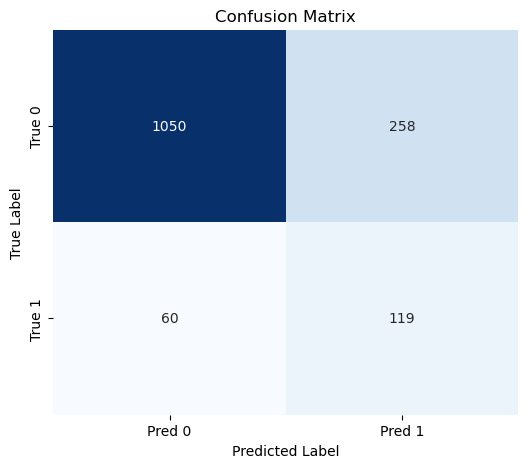

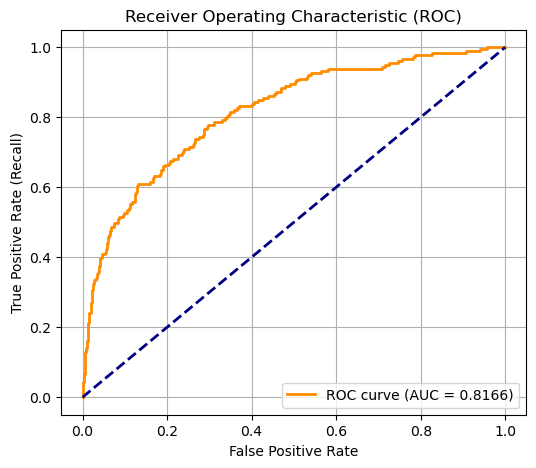

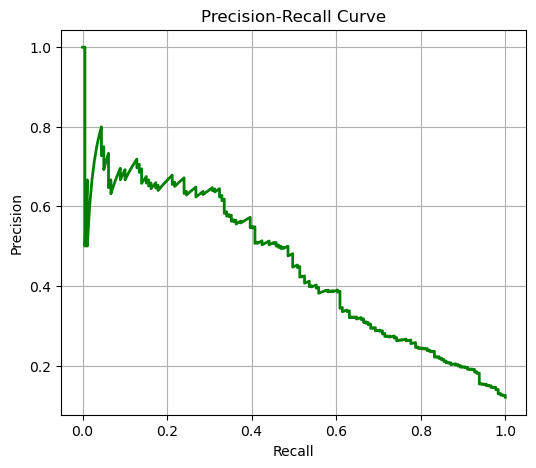

In [42]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Accuracy & Confusion Matrix
# -----------------------------
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"\n✅ Test Accuracy: {acc:.4f}")
print("\nConfusion Matrix:\n", cm)

# Confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# -----------------------------
# ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# -----------------------------
# Precision-Recall Curve
# -----------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

# 2

In [47]:
# ============================================================
# 🔥 FULL HEALTHCARE CLAIMS PIPELINE – DF_DRG VERSION
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, precision_score

# -------------------------
# CONFIG
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMB_DIM = 768  # embeddings are 768-dim
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3

# -------------------------
# TABULAR FEATURES
# -------------------------
tab_features = ["Payments", "LOS", "AGE", "Payments_log", "LOS_log"]

# -------------------------
# PREPARE NUMERIC FEATURES
# -------------------------
df = df_drg.copy()

num_cols = ["Payments", "LOS", "AGE"]
df[num_cols] = df[num_cols].astype(float)

# Outlier capping
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Log transform
df["Payments_log"] = np.log1p(df["Payments"])
df["LOS_log"] = np.log1p(df["LOS"])

# -------------------------
# TARGET
# -------------------------
df["Status_binary"] = df["InitialDeterminationStatus"].map({"APPROVED":0, "DENIED":1})

# -------------------------
# SCALER
# -------------------------
scaler = RobustScaler()
df[tab_features] = scaler.fit_transform(df[tab_features])

# -------------------------
# FIX EMBEDDINGS WITHOUT WARNINGS
# -------------------------
def fix_single(x, emb_dim=EMB_DIM):
    """Convert single embedding to tensor safely"""
    if x is None or (isinstance(x, float) and np.isnan(x)) or len(x)==0:
        return torch.zeros(emb_dim, device=DEVICE)
    if not isinstance(x, torch.Tensor):
        x = torch.as_tensor(x, dtype=torch.float32, device=DEVICE)
    else:
        x = x.detach().clone().to(DEVICE)
    if x.numel() < emb_dim:
        x = F.pad(x, (0, emb_dim - x.numel()))
    elif x.numel() > emb_dim:
        x = x[:emb_dim]
    return x

def fix_multi(x, emb_dim=EMB_DIM):
    """Convert multiple embeddings to (n_tokens, emb_dim)"""
    if x is None or (isinstance(x, float) and np.isnan(x)) or len(x)==0:
        return torch.zeros(1, emb_dim, device=DEVICE)
    if not isinstance(x, torch.Tensor):
        x = torch.as_tensor(x, dtype=torch.float32, device=DEVICE)
    else:
        x = x.detach().clone().to(DEVICE)
    if x.ndim == 1:
        return fix_single(x).unsqueeze(0)
    if x.shape[1] != emb_dim:
        diff = emb_dim - x.shape[1]
        if diff > 0:
            x = F.pad(x, (0, diff))
        else:
            x = x[:, :emb_dim]
    return x

# -------------------------
# DATASET
# -------------------------
class HealthDataset(Dataset):
    def __init__(self, df, tab_features=tab_features):
        # Check tab_features exist
        self.tab_features = [f for f in tab_features if f in df.columns]
        self.DRG = [fix_single(x) for x in df["DRG_EMB"]]
        self.PRIM = [fix_single(x) for x in df["PDX_EMB"]]
        self.MCC = [fix_multi(x) for x in df["MCC_EMB_POOLED"]]
        self.CC = [fix_multi(x) for x in df["CC_EMB_POOLED"]]
        self.PROC = [fix_multi(x) for x in df["PROC_EMB_POOLED"]]
        self.tab = torch.tensor(df[self.tab_features].values, dtype=torch.float32, device=DEVICE)
        self.y = torch.tensor(df["Status_binary"].values, dtype=torch.float32, device=DEVICE)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "DRG": self.DRG[idx],
            "PRIM": self.PRIM[idx],
            "MCC": self.MCC[idx],
            "CC": self.CC[idx],
            "PROC": self.PROC[idx],
            "tab": self.tab[idx],
            "y": self.y[idx]
        }

# Collate function with mean pooling for multi embeddings
def health_collate_fn(batch):
    return {
        "DRG": torch.stack([b["DRG"] for b in batch]),
        "PRIM": torch.stack([b["PRIM"] for b in batch]),
        "MCC": torch.stack([b["MCC"].mean(0) for b in batch]),
        "CC": torch.stack([b["CC"].mean(0) for b in batch]),
        "PROC": torch.stack([b["PROC"].mean(0) for b in batch]),
        "tab": torch.stack([b["tab"] for b in batch]),
        "y": torch.stack([b["y"] for b in batch])
    }

# -------------------------
# MODEL
# -------------------------
class HealthNN(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, tab_dim=len(tab_features)):
        super().__init__()
        self.fc1 = nn.Linear(emb_dim*5 + tab_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, batch):
        X = torch.cat([batch["DRG"], batch["PRIM"], batch["MCC"], batch["CC"], batch["PROC"], batch["tab"]], dim=1)
        x = F.relu(self.bn1(self.fc1(X)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))
        return self.out(x).squeeze(1)

# -------------------------
# SPLIT DATA
# -------------------------
df_train, df_temp = train_test_split(df, test_size=0.1, stratify=df["Status_binary"], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.2, stratify=df_temp["Status_binary"], random_state=42)

train_ds = HealthDataset(df_train)
val_ds = HealthDataset(df_val)
test_ds = HealthDataset(df_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=health_collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=health_collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=health_collate_fn)

# -------------------------
# MODEL + LOSS
# -------------------------
model = HealthNN().to(DEVICE)
# Use class-balanced BCE
pos = df_train["Status_binary"].sum()
neg = len(df_train) - pos
pos_weight = torch.tensor([neg/pos], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# -------------------------
# TRAINING LOOP
# -------------------------
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = {k:v.to(DEVICE) if torch.is_tensor(v) else v for k,v in batch.items()}
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch["y"])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model.eval()
    y_val, y_prob = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k:v.to(DEVICE) if torch.is_tensor(v) else v for k,v in batch.items()}
            logits = model(batch)
            y_val.append(batch["y"].cpu())
            y_prob.append(torch.sigmoid(logits).cpu())
    y_val = torch.cat(y_val)
    y_prob = torch.cat(y_prob)
    
    # Threshold tuning: for DENIED, try 0.55–0.6
    threshold = 0.57
    y_pred = (y_prob >= threshold).int()
    
    print(f"Epoch {epoch+1} | Loss {total_loss:.4f} | Recall {recall_score(y_val, y_pred):.4f} | "
          f"Precision {precision_score(y_val, y_pred):.4f} | F1 {f1_score(y_val, y_pred):.4f}")

Epoch 1 | Loss 2107.1193 | Recall 0.7214 | Precision 0.2677 | F1 0.3905
Epoch 2 | Loss 1992.1386 | Recall 0.8245 | Precision 0.2240 | F1 0.3523
Epoch 3 | Loss 1931.1726 | Recall 0.7925 | Precision 0.2361 | F1 0.3638
Epoch 4 | Loss 1895.2809 | Recall 0.5864 | Precision 0.3440 | F1 0.4336
Epoch 5 | Loss 1862.5549 | Recall 0.5752 | Precision 0.4470 | F1 0.5030
Epoch 6 | Loss 1852.3748 | Recall 0.8217 | Precision 0.2488 | F1 0.3820
Epoch 7 | Loss 1837.6989 | Recall 0.5710 | Precision 0.3480 | F1 0.4325
Epoch 8 | Loss 1824.8989 | Recall 0.7201 | Precision 0.3114 | F1 0.4348
Epoch 9 | Loss 1812.4705 | Recall 0.5348 | Precision 0.4414 | F1 0.4836
Epoch 10 | Loss 1795.7538 | Recall 0.6978 | Precision 0.3193 | F1 0.4381
Epoch 11 | Loss 1791.6327 | Recall 0.7131 | Precision 0.3269 | F1 0.4483
Epoch 12 | Loss 1779.2033 | Recall 0.7103 | Precision 0.3050 | F1 0.4268
Epoch 13 | Loss 1776.6228 | Recall 0.6922 | Precision 0.3409 | F1 0.4568
Epoch 14 | Loss 1753.8759 | Recall 0.5348 | Precision 0.4379

# PREV

In [25]:
# ============================================================
# 🔥 FULL HEALTHCARE CLAIMS PIPELINE – DIMENSION-SAFE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
emb_dim = 128  # fixed embedding dimension



# ============================================================
# Helper functions for embedding padding

import math

def fix_single(x, emb_dim=128):
    # Handle None, NaN, empty list → zeros
    if x is None or (isinstance(x, float) and math.isnan(x)) or (hasattr(x, "__len__") and len(x) == 0):
        return torch.zeros(emb_dim)
    
    # Convert to tensor
    x = torch.tensor(x, dtype=torch.float32)
    
    # Pad or trim to emb_dim
    if x.numel() < emb_dim:
        x = F.pad(x, (0, emb_dim - x.numel()))
    elif x.numel() > emb_dim:
        x = x[:emb_dim]
    return x

def fix_multi(x, emb_dim=128):
    if x is None or (isinstance(x, float) and math.isnan(x)) or (hasattr(x, "__len__") and len(x) == 0):
        return torch.zeros(1, emb_dim)
    
    x = torch.tensor(x, dtype=torch.float32)
    
    # Single row → reshape
    if x.ndim == 1:
        if x.numel() < emb_dim:
            x = F.pad(x, (0, emb_dim - x.numel()))
        elif x.numel() > emb_dim:
            x = x[:emb_dim]
        return x.view(1, emb_dim)
    
    # Multi-row → pad each row
    if x.shape[1] != emb_dim:
        diff = emb_dim - x.shape[1]
        if diff > 0:
            x = F.pad(x, (0, diff))
        else:
            x = x[:, :emb_dim]
    return x.view(-1, emb_dim)

# ============================================================
# Dataset
# ============================================================
class HealthDataset(Dataset):
    def __init__(self, df, emb_dim=emb_dim):
        self.DRG = [fix_single(x, emb_dim) for x in df["DRG_EMB_128"]]
        self.PRIM = [fix_single(x, emb_dim) for x in df["PDX_EMB_128"]]
        self.MCC = [fix_multi(x, emb_dim) for x in df["MCC_EMB_LIST"]]
        self.CC = [fix_multi(x, emb_dim) for x in df["CC_EMB_LIST"]]
        self.PROC = [fix_multi(x, emb_dim) for x in df["PROC_EMB_LIST"]]
        self.LOS = torch.tensor(df["LOS"].values, dtype=torch.float32)
        self.Payments = torch.tensor(df["Payments"].values, dtype=torch.float32)
        self.y = torch.tensor(df["Status_binary"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "DRG": self.DRG[idx],
            "PRIM": self.PRIM[idx],
            "MCC": self.MCC[idx],
            "CC": self.CC[idx],
            "PROC": self.PROC[idx],
            "LOS": self.LOS[idx].unsqueeze(0),
            "Payments": self.Payments[idx].unsqueeze(0),
            "y": self.y[idx]
        }

# Collate function
def health_collate_fn(batch):
    return {
        "DRG": [b["DRG"] for b in batch],
        "PRIM": [b["PRIM"] for b in batch],
        "MCC": [b["MCC"] for b in batch],
        "CC": [b["CC"] for b in batch],
        "PROC": [b["PROC"] for b in batch],
        "LOS": torch.stack([b["LOS"] for b in batch]),
        "Payments": torch.stack([b["Payments"] for b in batch]),
        "y": torch.stack([b["y"] for b in batch]),
    }

# ============================================================
# Attention Pooling
# ============================================================
class AttentionPooling(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.query = nn.Parameter(torch.randn(emb_dim))
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)
        self.register_buffer("zero_vec", torch.zeros(emb_dim))

    def forward(self, X):
        # X shape: (n_tokens, emb_dim)
        if X.shape[0] == 0:
            return self.zero_vec
        elif X.shape[0] == 1:
            return X.squeeze(0)
        Q = self.query.unsqueeze(0)
        K = self.key(X)
        V = self.value(X)
        attn = torch.softmax(Q @ K.T / np.sqrt(K.shape[1]), dim=-1)
        return (attn @ V).squeeze(0)

# ============================================================
# Neural Network
# ============================================================
class HealthNN(nn.Module):
    def __init__(self, emb_dim=emb_dim):
        super().__init__()
        self.mcc_attn = AttentionPooling(emb_dim)
        self.cc_attn = AttentionPooling(emb_dim)
        self.proc_attn = AttentionPooling(emb_dim)
        self.fc1 = nn.Linear(emb_dim*5 + 2, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, batch):
        drg = torch.stack(batch["DRG"])
        prim = torch.stack(batch["PRIM"])
        mcc = torch.stack([self.mcc_attn(x) for x in batch["MCC"]])
        cc = torch.stack([self.cc_attn(x) for x in batch["CC"]])
        proc = torch.stack([self.proc_attn(x) for x in batch["PROC"]])
        los = torch.stack([x for x in batch["LOS"]])
        payments = torch.stack([x for x in batch["Payments"]])
        X = torch.cat([drg, prim, mcc, cc, proc, los, payments], dim=1)
        x = F.relu(self.bn1(self.fc1(X)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))
        return self.out(x).squeeze(1)

# ============================================================
# Train / Validation / Test Split
# ============================================================
df_train, df_temp = train_test_split(df_ml_new, test_size=0.1,
                                     stratify=df_ml_new["Status_binary"], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.2,
                                   stratify=df_temp["Status_binary"], random_state=42)

train_ds = HealthDataset(df_train)
val_ds = HealthDataset(df_val)
test_ds = HealthDataset(df_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=health_collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=health_collate_fn)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=health_collate_fn)

# ============================================================
# Model + Loss (imbalance aware)
# ============================================================
model = HealthNN(emb_dim=emb_dim).to(device)
pos = df_train["Status_binary"].sum()
neg = len(df_train) - pos
pos_weight = torch.tensor([neg / pos], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# ============================================================
# Training Loop
# ============================================================
EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = {k:v.to(device) if torch.is_tensor(v) else v for k,v in batch.items()}
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch["y"])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    y_val, y_prob = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k:v.to(device) if torch.is_tensor(v) else v for k,v in batch.items()}
            logits = model(batch)
            y_val.append(batch["y"].cpu())
            y_prob.append(torch.sigmoid(logits).cpu())
    y_val = torch.cat(y_val)
    y_prob = torch.cat(y_prob)
    y_pred = (y_prob >= 0.5).int()
    print(f"Epoch {epoch+1} | Loss {total_loss:.4f} | Recall {recall_score(y_val, y_pred):.4f} | F1 {f1_score(y_val, y_pred):.4f}")



C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_2044\1704298368.py:42: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  x = torch.tensor(x, dtype=torch.float32)


Epoch 1 | Loss 2541.2040 | Recall 0.7270 | F1 0.2453
Epoch 2 | Loss 2494.3257 | Recall 0.6699 | F1 0.2561
Epoch 3 | Loss 2442.6227 | Recall 0.7145 | F1 0.2750
Epoch 4 | Loss 2386.7153 | Recall 0.6574 | F1 0.2918
Epoch 5 | Loss 2386.1795 | Recall 0.7409 | F1 0.2794
Epoch 6 | Loss 2348.7582 | Recall 0.6184 | F1 0.3141
Epoch 7 | Loss 2314.4027 | Recall 0.7646 | F1 0.3044
Epoch 8 | Loss 2264.7302 | Recall 0.6448 | F1 0.3401
Epoch 9 | Loss 2234.4659 | Recall 0.8384 | F1 0.3098
Epoch 10 | Loss 2213.3862 | Recall 0.6950 | F1 0.3491
Epoch 11 | Loss 2228.6496 | Recall 0.9429 | F1 0.2620
Epoch 12 | Loss 2210.5321 | Recall 0.6504 | F1 0.3502
Epoch 13 | Loss 2198.0911 | Recall 0.4304 | F1 0.3936
Epoch 14 | Loss 2185.9858 | Recall 0.6699 | F1 0.3663
Epoch 15 | Loss 2183.3397 | Recall 0.7897 | F1 0.3264
Epoch 16 | Loss 2187.9291 | Recall 0.6950 | F1 0.3662
Epoch 17 | Loss 2184.2383 | Recall 0.8231 | F1 0.3309
Epoch 18 | Loss 2173.7708 | Recall 0.8273 | F1 0.3008
Epoch 19 | Loss 2157.4279 | Recall 0.

In [40]:
model.eval()
y_true, y_prob = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
        logits = model(batch)
        y_true.append(batch["y"].cpu())
        y_prob.append(torch.sigmoid(logits).cpu())

y_true = torch.cat(y_true).numpy()
y_prob = torch.cat(y_prob).numpy()

# ✅ Use fixed threshold
best_thr = 0.55

print("\n✅ Best Threshold:", best_thr)

# Apply threshold
y_pred = (y_prob >= best_thr).astype(int)

# Final report
print("\n📊 Final Test Report\n")
print(classification_report(y_true, y_pred, digits=4))


✅ Best Threshold: 0.55

📊 Final Test Report

              precision    recall  f1-score   support

         0.0     0.9484    0.6881    0.7975      1308
         1.0     0.2416    0.7263    0.3626       179

    accuracy                         0.6927      1487
   macro avg     0.5950    0.7072    0.5801      1487
weighted avg     0.8633    0.6927    0.7452      1487



In [41]:
# ============================================================
# 💾 SAVE MODEL
# ============================================================

save_path = "20260326_health_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "emb_dim": emb_dim,
    "threshold": best_thr
}, save_path)

print(f"✅ Model saved to {save_path}")

✅ Model saved to 20260326_health_model.pth


In [42]:
# ============================================================
# 📦 LOAD MODEL
# ============================================================

def load_model(model_path, device="cpu"):
    checkpoint = torch.load(model_path, map_location=device)

    model = HealthNN(emb_dim=checkpoint["emb_dim"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    threshold = checkpoint.get("threshold", 0.55)

    return model, threshold

In [44]:
model, threshold = load_model("20260326_health_model.pth")

In [46]:
threshold

0.55

In [45]:
model

HealthNN(
  (mcc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (cc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (proc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc1): Linear(in_features=642, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=1, bias=True)
)

In [43]:
print(model)

HealthNN(
  (mcc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (cc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (proc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc1): Linear(in_features=642, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=1, bias=True)
)



✅ Test Accuracy: 0.6927

Confusion Matrix:
 [[900 408]
 [ 49 130]]


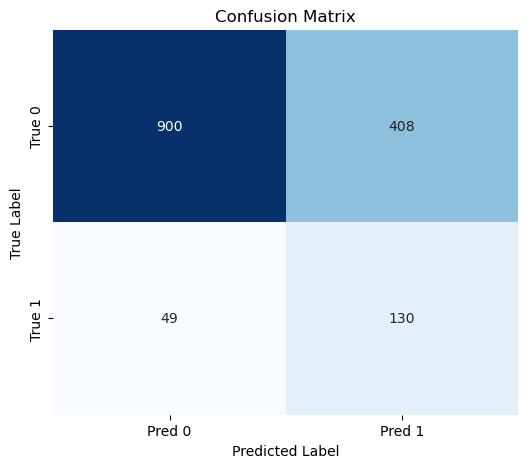

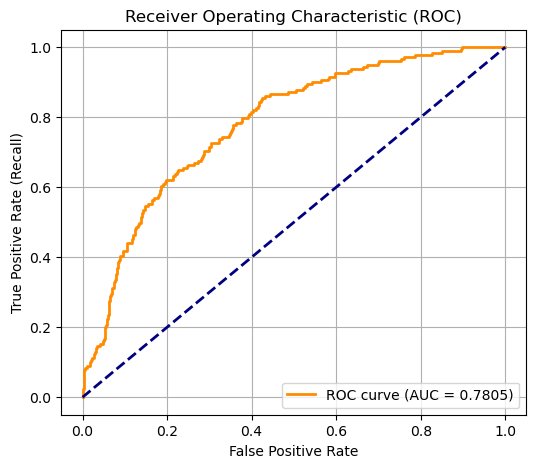

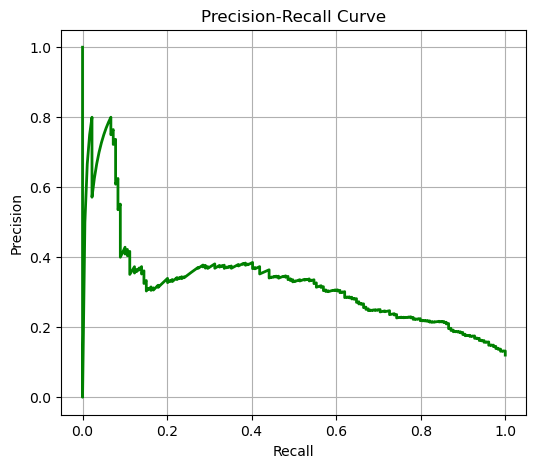

In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Accuracy & Confusion Matrix
# -----------------------------
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"\n✅ Test Accuracy: {acc:.4f}")
print("\nConfusion Matrix:\n", cm)

# Confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# -----------------------------
# ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# -----------------------------
# Precision-Recall Curve
# -----------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [49]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import pickle

torch.manual_seed(42)

projection = nn.Linear(768, 128)
torch.save(projection.state_dict(), "projection_768_to_128.pth")


def process(df, col):
    df[col] = df[col].apply(
        lambda x: np.fromstring(x.strip("[]"), sep=' ') if isinstance(x, str) else x
    )
    emb = torch.tensor(np.vstack(df[col].values), dtype=torch.float32)
    return projection(emb).detach().numpy()


# DRG
drg = pd.read_excel(r"C:\Arun_MIX\Model\20260325_DRG_Emb_Clinical_bert.xlsx")
drg["DRG_EMB_128"] = list(process(drg, "DRG_EMBEDDING"))
drg["DRG_Code"] = drg["DRG_TEXT"].str.extract(r"DRG Code:\s*(\d+)")[0]
drg_dict = dict(zip(drg["DRG_Code"], drg["DRG_EMB_128"]))

# ICD
icd = pd.read_excel(r"C:\Arun_MIX\Model\20260325_ICD_Emb_Clinical_bert.xlsx")
icd["ICD_EMB_128"] = list(process(icd, "ICD_EMBEDDING"))
icd_dict = dict(zip(icd["SDX_CODE"], icd["ICD_EMB_128"]))

# PROC
proc = pd.read_excel(r"C:\Arun_MIX\Model\20260325_PROC_Emb_Clinical_bert.xlsx")
proc["PROC_EMB_128"] = list(process(proc, "PROC_EMBEDDING"))
proc_dict = dict(zip(proc["PX_CODE"], proc["PROC_EMB_128"]))

with open("embeddings.pkl", "wb") as f:
    pickle.dump({
        "drg_dict": drg_dict,
        "icd_dict": icd_dict,
        "proc_dict": proc_dict
    }, f)

print("✅ embeddings.pkl created")

✅ embeddings.pkl created


# prev

In [39]:
# ============================================================
# Test Evaluation + Balanced Threshold
# ============================================================
model.eval()
y_true, y_prob = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k:v.to(device) if torch.is_tensor(v) else v for k,v in batch.items()}
        logits = model(batch)
        y_true.append(batch["y"].cpu())
        y_prob.append(torch.sigmoid(logits).cpu())

y_true = torch.cat(y_true).numpy()
y_prob = torch.cat(y_prob).numpy()
best_thr, best_bal = 0.5, 0
for t in np.linspace(0.05, 0.95, 200):
    y_pred = (y_prob >= t).astype(int)
    r0 = recall_score(y_true, y_pred, pos_label=0)
    r1 = recall_score(y_true, y_pred, pos_label=1)
    bal = (r0 + r1)/2
    if bal > best_bal:
        best_bal, best_thr = bal, t

print("\n✅ Best Threshold:", round(best_thr,4))
print("✅ Balanced Recall:", round(best_bal,4))
y_pred = (y_prob >= best_thr).astype(int)
print("\n📊 Final Test Report\n")
print(classification_report(y_true, y_pred, digits=4))


✅ Best Threshold: 0.4344
✅ Balanced Recall: 0.7142

📊 Final Test Report

              precision    recall  f1-score   support

         0.0     0.9674    0.5680    0.7158      1308
         1.0     0.2142    0.8603    0.3430       179

    accuracy                         0.6032      1487
   macro avg     0.5908    0.7142    0.5294      1487
weighted avg     0.8768    0.6032    0.6709      1487



# both pre and post


✅ Test Accuracy: 0.7054

Confusion Matrix:
 [[924 384]
 [ 54 125]]


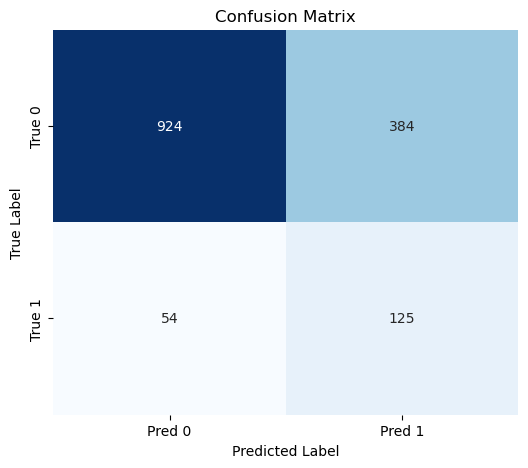

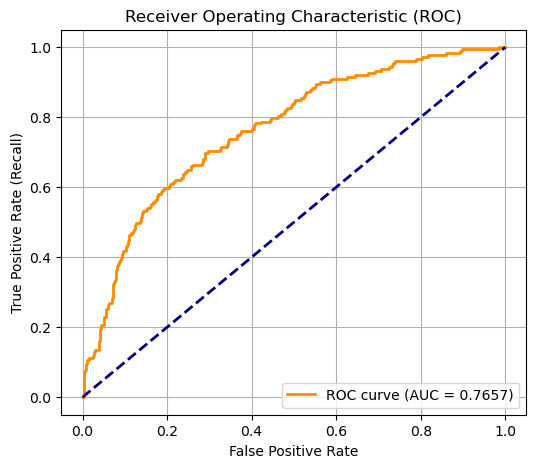

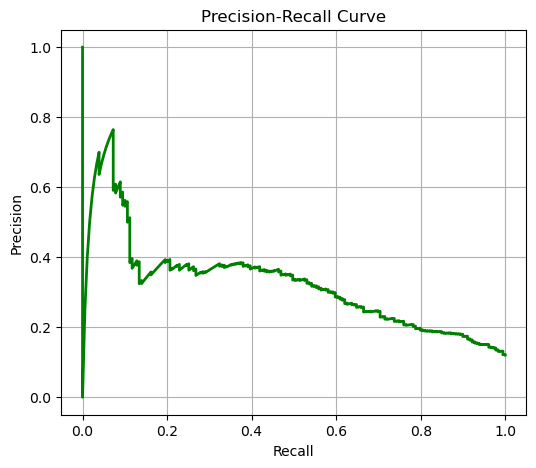

In [90]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Accuracy & Confusion Matrix
# -----------------------------
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"\n✅ Test Accuracy: {acc:.4f}")
print("\nConfusion Matrix:\n", cm)

# Confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# -----------------------------
# ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# -----------------------------
# Precision-Recall Curve
# -----------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

# prediction

In [91]:
import torch
import torch.nn.functional as F

def predict_claim_from_codes(
    model,
    drg_code, prim_dx, mcc_list=None, cc_list=None, proc_list=None,
    LOS=0.0, Payments=0.0,
    drg_dict=None, icd_dict=None, proc_dict=None,
    emb_dim=128,
    threshold=0.4796
):
    model.eval()
    
    # -------------------------
    # Helper functions
    # -------------------------
    def fix_single(x):
        if x is None:
            return torch.zeros(emb_dim)
        x = torch.tensor(x, dtype=torch.float32)
        if x.numel() < emb_dim:
            x = F.pad(x, (0, emb_dim - x.numel()))
        elif x.numel() > emb_dim:
            x = x[:emb_dim]
        return x

    def fix_multi(code_list, dict_map):
        if code_list is None or len(code_list) == 0:
            return torch.zeros(1, emb_dim)
        embs = []
        for code in code_list:
            emb = dict_map.get(code, [0.0]*emb_dim)
            embs.append(emb)
        embs = torch.tensor(embs, dtype=torch.float32)
        return embs.view(-1, emb_dim)
    
    # -------------------------
    # Map codes → embeddings
    # -------------------------
    drg = fix_single(drg_dict.get(drg_code, [0.0]*emb_dim)).unsqueeze(0).to(device)
    prim = fix_single(icd_dict.get(prim_dx, [0.0]*emb_dim)).unsqueeze(0).to(device)
    mcc = fix_multi(mcc_list, icd_dict).to(device)
    cc = fix_multi(cc_list, icd_dict).to(device)
    proc = fix_multi(proc_list, proc_dict).to(device)
    
    los = torch.tensor([[LOS]], dtype=torch.float32, device=device)
    payments = torch.tensor([[Payments]], dtype=torch.float32, device=device)
    
    # -------------------------
    # Attention pooling + forward
    # -------------------------
    with torch.no_grad():
        mcc_attn = torch.stack([model.mcc_attn(mcc)])
        cc_attn = torch.stack([model.cc_attn(cc)])
        proc_attn = torch.stack([model.proc_attn(proc)])

        X = torch.cat([drg, prim, mcc_attn, cc_attn, proc_attn, los, payments], dim=1)
        logits = model.out(F.relu(model.fc3(F.relu(model.bn2(model.fc2(F.relu(model.bn1(model.fc1(X)))))))))
        prob_denied = torch.sigmoid(logits).item()
        pred_class = "Denied" if prob_denied >= threshold else "Approved"
    
    return pred_class, prob_denied

In [92]:
# Example codes
drg_code = "175"
prim_dx = "I2699"
mcc_list = ["N186"]
cc_list = ["I132,I483,I5032,N2581"]
proc_list = ["5A1D70Z"]

LOS_example = 3
Payments_example = 9198.88

pred_class, denied_prob = predict_claim_from_codes(
    model,
    drg_code, prim_dx, mcc_list, cc_list, proc_list,
    LOS_example, Payments_example,
    drg_dict=drg_dict, icd_dict=icd_dict, proc_dict=proc_dict,
    threshold=0.4796
)

print(f"Prediction: {pred_class}")
print(f"Confidence score for Denied: {denied_prob:.4f}")

Prediction: Denied
Confidence score for Denied: 0.5963
